In [1]:
%cd "C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4"

C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4


C:\Users\asmaa\PycharmProjects\pythonProject\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [36]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
# !pip install scikit-optimize

In [58]:
# from skopt import gp_minimize
# from skopt import space

In [59]:
import devices
import models
import samplers
import trainers
import utils

import torch
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat

In [60]:
# parameters
lambd = 1

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd
dx = (lambd / 20) * k_0

# normalized simulation lengths
substrate_length = (6 * lambd) * k_0
core_length = (2 * lambd) * k_0
cladding_length = (6 * lambd) * k_0

# refractive indices
n_substrate = 1.44
n_core = 1.55
n_cladding = 1.44

In [61]:
study = 'TM'
field_type = 'E'

In [62]:
RIs = [n_substrate, n_core, n_cladding]
lengths = [substrate_length, core_length, cladding_length]

In [63]:
reference_device = devices.SlabWaveguide(RIs, lambd, lengths, study=study, field_type=field_type)

In [64]:
memory_type = torch.device('cpu')
dtype = torch.float64
torch.manual_seed(42)
num_modes = 3

In [65]:
base_model = models.discontinuity_capturing_network(1, 64, num_modes, 2, 'Siren')
optimzer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[2000, 3000, 4000], gamma=0.2)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 4547


In [66]:
device = devices.SlabWaveguideWithPINNs(RIs, lambd, lengths, study, field_type, base_model, True)

In [55]:
train_agent = trainers.Trainer(dtype, device, memory_type, [samplers.uniform_grid], optimzer, scheduler, dx)

In [32]:
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[10, 0.5, 2, 1, 1, 1], verbose=1, sample_new=False)

num PDE samples 699
num rayleigh samples 699
iteration 1 loss1 is 0.54893, loss2 is 0.00401, loss3 is -2.13442, loss4 is 0.9168, loss5 is 0.69872, loss6 is 4.80385
iteration 1001 loss1 is 0.06964, loss2 is 0.00453, loss3 is -4.14247, loss4 is 0.00208, loss5 is 0.02398, loss6 is 0.17653
iteration 2001 loss1 is 0.05799, loss2 is 0.00521, loss3 is -4.14628, loss4 is 0.00178, loss5 is 0.0146, loss6 is 0.22869
iteration 3001 loss1 is 0.02286, loss2 is 0.00723, loss3 is -4.16205, loss4 is 0.00035, loss5 is 0.00888, loss6 is 0.0656
iteration 4001 loss1 is 0.00489, loss2 is 0.00769, loss3 is -4.1658, loss4 is 0.0, loss5 is 0.001, loss6 is 0.00989
iteration 5001 loss1 is 0.00262, loss2 is 0.00781, loss3 is -4.16582, loss4 is 0.0, loss5 is 8e-05, loss6 is 0.00153
iteration 6001 loss1 is 0.00248, loss2 is 0.00792, loss3 is -4.16587, loss4 is 0.0, loss5 is 0.00012, loss6 is 0.00114
iteration 7001 loss1 is 0.00261, loss2 is 0.00803, loss3 is -4.16589, loss4 is 0.0, loss5 is 0.00027, loss6 is 0.0022

# FD Performance

adjusting analytic solution for Ex in a TM study
**********
mode errors
**********
relative error for mode 0 is 1.48697%
**********
**********
relative error for mode 1 is 1.98576%
**********
**********
relative error for mode 2 is 6.30739%
**********


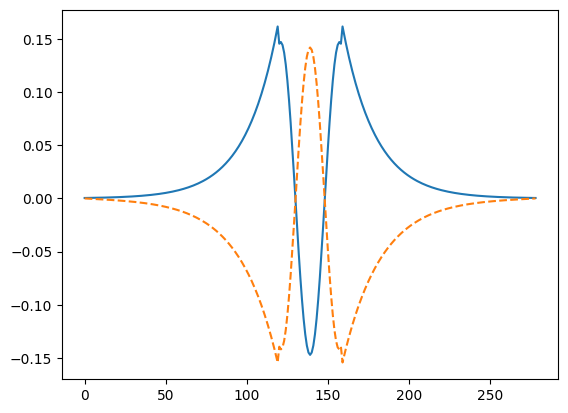

In [67]:
fd_device = devices.SlabWaveguideWithFD(RIs, lambd, lengths, study, field_type, dx)
_, x, u = fd_device.evaluate(num_modes)
utils.compare_against_analytic(fd_device, x, torch.from_numpy(u));

evalution points are at an error of 0.0%


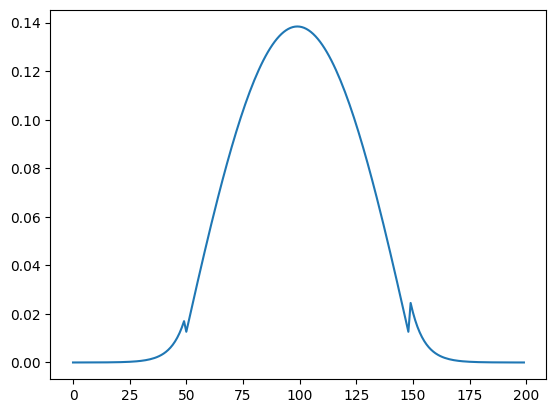

In [161]:
mode_errors = []
num_modes = len(u.T)
evaluation_points, eigen_modes_analytic, eigen_funcs_analytic = reference_device.evaluate_analytical(x, num_modes)

if reference_device.study == 'TM':
  evaluation_pts_error = (torch.mean((torch.from_numpy(evaluation_points).reshape(-1) - x.reshape(-1)) ** 2) / np.mean(
          evaluation_points.reshape(-1) ** 2)) ** 0.5 * 100
  print(f'evalution points are at an error of {round(evaluation_pts_error.item(), 5)}%')

  if reference_device.field_type=='E':
    eigen_funcs_analytic = eigen_funcs_analytic / device.refractive_index(evaluation_points, format='numpy')**2
    eigen_funcs_analytic /= np.linalg.norm(eigen_funcs_analytic, axis=-1, keepdims=True)
    plt.plot(eigen_funcs_analytic[0, 250:450])

# NN Performance

adjusting analytic solution for Ex in a TM study
**********
mode errors
**********
relative error for mode 0 is 0.72223%
**********
**********
relative error for mode 1 is 1.32401%
**********


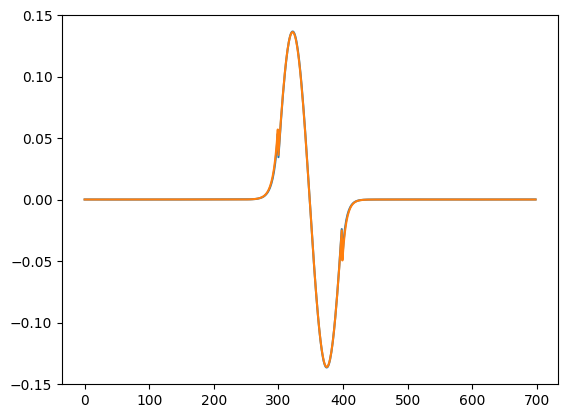

In [35]:
augmented_x = torch.cat((torch.from_numpy(evaluation_points).reshape(-1, 1), device.refractive_index(torch.from_numpy(evaluation_points).reshape(-1, 1), format='torch')**2), dim=-1).to(memory_type)
predictions = device.underlying_model(augmented_x)
prediction_normed = predictions.detach().cpu() / torch.linalg.norm(predictions.detach().cpu(), dim=0, keepdims=True)

utils.compare_against_analytic(reference_device, x, prediction_normed.detach().cpu());

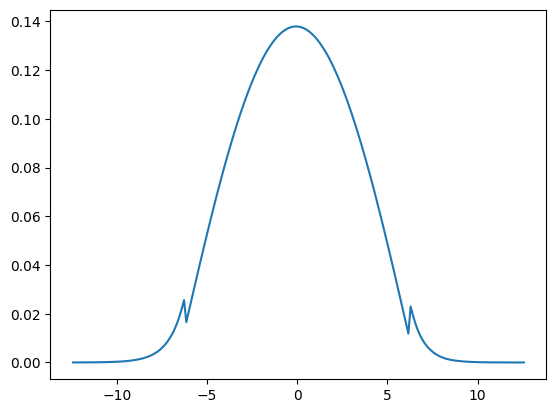

In [36]:
plt.plot(evaluation_points[250:450], prediction_normed[250:450, 0].detach());

# Further Plots

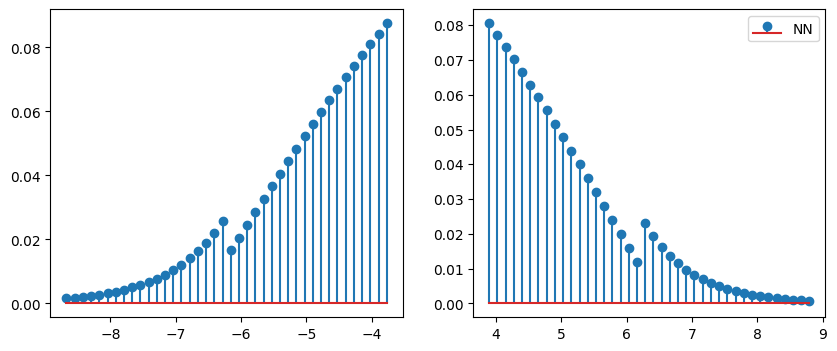

In [37]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.stem(evaluation_points[280:320], prediction_normed[280:320, 0].detach(), label='NN');
plt.subplot(1, 2, 2)
plt.stem(evaluation_points[380:420], prediction_normed[380:420, 0].detach(), label='NN');
# plt.stem(evaluation_points[250:450], eigen_funcs_analytic[1, 250:450], label='analytic')
plt.legend();

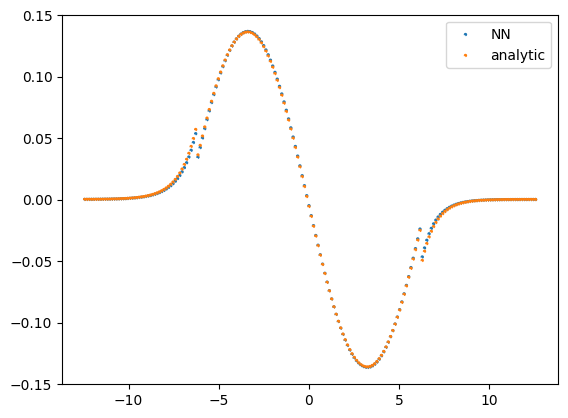

In [38]:
plt.scatter(evaluation_points[250:450], prediction_normed[250:450, 1].detach(), label='NN', linestyle='dashed', s=2);
plt.scatter(evaluation_points[250:450], eigen_funcs_analytic[1, 250:450], label='analytic', linestyle='dashed', s=2)
plt.legend();

In [ ]:
x_tensor = torch.from_numpy(x)
x_tensor.requires_grad = True
x_augmented = torch.cat((x_tensor.reshape(-1, 1), device.refractive_index(torch.from_numpy(x).reshape(-1, 1), format='torch')**2), dim=-1)

In [ ]:
_**(1/2), '\n', reference_device.evaluate_analytical(x, 2)[1], '\n', [device.calculate_eigen_value(x_augmented.to(memory_type), 0).item()**(1/2), device.calculate_eigen_value(x_augmented.to(memory_type), 1).item()**(1/2)]

(array([1.68305023, 1.63153231]),
 '\n',
 array([1.68336482, 1.63279678]),
 '\n',
 [1.6832016156185146, 1.63268599111474])

In [ ]:
mode = reference_device.evaluate_analytical(x, 1)[2][0]
mode = mode.reshape(-1)
mode = mode/device.refractive_index(torch.from_numpy(x).reshape(-1), format='numpy')**2
discontinuities_indices = device.get_discontinuities_index(torch.from_numpy(x))
print('discontinuities at index:', [item.item() for item in discontinuities_indices])
print('field profile ratios are', round((n_core**2)/(n_substrate**2), 5), 'and', round((n_cladding**2)/(n_core**2), 5))
print('mode ratios around the first discontinuity', mode[296:306]/mode[295:305])
print('mode ratios around the second discontinuity', mode[396:406]/mode[395:405])

discontinuities at index: [299, 399]
field profile ratios are 2.00694 and 0.34602
mode ratios around the first discontinuity [1.15992261 1.15992261 1.15992261 1.15992261 0.6463798  1.22824886
 1.18494403 1.15518957 1.13345249 1.1168511 ]
mode ratios around the second discontinuity [0.83555863 0.80230717 0.75270587 1.93795044 0.84352371 0.84352371
 0.84352371 0.84352371 0.84352371 0.84352371]


In [ ]:
pred_normed_tensor = predictions[:, 0].detach().cpu()
discontinuities_indices = device.get_discontinuities_index(torch.from_numpy(x))
print('discontinuities at index:', [item.item() for item in discontinuities_indices])
print('field profile ratios are', round((n_core**2)/(n_substrate**2), 5), 'and', round((n_cladding**2)/(n_core**2), 5))
print('mode ratios around the first discontinuity:')
print((pred_normed_tensor[295:305]/pred_normed_tensor[296:306]).numpy())
print('mode ratios around the second discontinuity:')
print((pred_normed_tensor[395:405]/pred_normed_tensor[396:406]).numpy())

discontinuities at index: [299, 399]
field profile ratios are 2.00694 and 0.34602
mode ratios around the first discontinuity:
[0.85621977 0.85738209 0.85979854 0.86343849 1.55019133 0.81163477
 0.83968688 0.86111609 0.87805413 0.89176486]
mode ratios around the second discontinuity:
[1.20395466 1.25566266 1.33811975 0.51811805 1.18507286 1.18889037
 1.1902344  1.18946969 1.18728006 1.18453595]


In [ ]:
mode = fd_device.evaluate(1)[2]
mode = mode.reshape(-1)
mode = mode/device.refractive_index(torch.from_numpy(x).reshape(-1), format='numpy')**2
discontinuities_indices = device.get_discontinuities_index(torch.from_numpy(x))
print('discontinuities at index:', [item.item() for item in discontinuities_indices])
print('field profile ratios are', round((n_core**2)/(n_substrate**2), 5), 'and', round((n_cladding**2)/(n_core**2), 5))
print('mode ratios around the first discontinuity', mode[295:305]/mode[296:306])
print('mode ratios around the second discontinuity', mode[395:405]/mode[396:406])

discontinuities at index: [299, 399]
field profile ratios are 2.00694 and 0.34602
mode ratios around the first discontinuity [0.86229196 0.86229196 0.86229196 0.86229196 3.24797297 0.79519843
 0.83063649 0.85582879 0.87468731 0.88935754]
mode ratios around the second discontinuity [1.21845817 1.28100624 1.3925865  0.16285951 1.18520251 1.18520251
 1.18520251 1.18520251 1.18520251 1.18520251]
